# Projekt: Credit Card Customer Churn Prediction

**Ziel:** Abwandernde Kreditkarten-Kunden (`Attrition_Flag`) vorhersagen und ein **Ranking** der aktuell gefährdetsten Bestandskunden erstellen.

**Workflow:**
- Daten pflegen (Spalten bereinigen, fehlende Werte klären, Daten transformieren)
- Training: Train/Test Split **80/20** + **N-Fold Cross Validation**
- Auswertung: **Confusion Matrix**, **Precision / Recall / F1**
- Anwenden: Vorhersage & Ranking

## 1) Setup & Daten laden

**Voraussetzung:**
- Lege die Kaggle-Datei `BankChurners.csv` in den Ordner `dataset/`
  → Pfad: `dataset/BankChurners.csv`

In [3]:
# Basis-Imports
import sys
print(sys.executable)

import os
import numpy as np
import pandas as pd

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

import joblib

# Visualisierung (kein seaborn)
import matplotlib.pyplot as plt

RANDOM_STATE = 42

/Users/kapfi/Library/Mobile Documents/com~apple~CloudDocs/Workspace/CreditCardFraud/.venv/bin/python


In [4]:
DATA_PATH = "dataset/BankChurners.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Datei nicht gefunden: {DATA_PATH}\n"
        "👉 Lege BankChurners.csv in den Ordner 'data/' (neben dem Notebook)."
    )

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (10127, 22)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 2) Erste Checks (EDA light)

Wir prüfen:
- Datentypen
- Zielvariable / Klassenverteilung
- potenzielle Problemspalten (ID, Leakage/Artefakte)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 22 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   Attrition_Flag                                                                                                                      10127 non-null  object 
 1   Customer_Age                                                                                                                        10127 non-null  int64  
 2   Gender                                                                                                                              10127 non-null  object 
 3   Dependent_count                                                                  

In [6]:
TARGET_COL = "Attrition_Flag"
if TARGET_COL not in df.columns:
    raise KeyError(f"Spalte '{TARGET_COL}' nicht gefunden. Spalten: {list(df.columns)}")

df[TARGET_COL].value_counts(dropna=False)

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

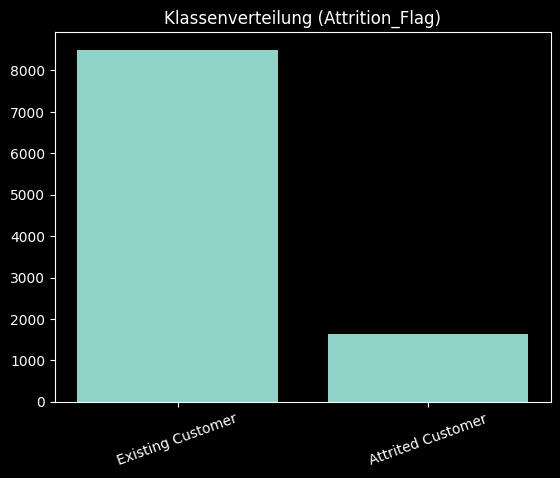

In [7]:
# Klassenanteile (Attrited vs Existing) - zur schnellen Kontrolle
counts = df[TARGET_COL].value_counts()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Klassenverteilung (Attrition_Flag)")
plt.xticks(rotation=20)
plt.show()

## 3) Datenbereinigung (idiotensicher)

**Typische Drops:**
- `CLIENTNUM` ist nur eine ID → raus
- `Naive_Bayes_Classifier_...` sind im Datensatz oft enthalten → **Leakage/Artefakte** → raus

**Zielvariable mappen:**
- `Existing Customer` → 0
- `Attrited Customer` → 1

In [8]:
# 1) Zielvariable in 0/1
df = df.copy()

mapping = {
    "Existing Customer": 0,
    "Attrited Customer": 1
}

df[TARGET_COL] = df[TARGET_COL].map(mapping)

if df[TARGET_COL].isna().any():
    # Falls es unerwartete Werte gibt, brechen wir ab (sauber!)
    bad = df.loc[df[TARGET_COL].isna(), TARGET_COL].unique()
    raise ValueError(f"Unerwartete Werte in {TARGET_COL}: {bad}")

df[TARGET_COL].value_counts()

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

In [9]:
# 2) Drops (ID + Leakage-Spalten)
drop_cols = []
if "CLIENTNUM" in df.columns:
    drop_cols.append("CLIENTNUM")

leak_cols = [c for c in df.columns if c.startswith("Naive_Bayes_Classifier_")]
drop_cols += leak_cols

print("Drop cols:", drop_cols)

X = df.drop(columns=drop_cols + [TARGET_COL])
y = df[TARGET_COL]
print("X shape:", X.shape, "| y shape:", y.shape)

Drop cols: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
X shape: (10127, 19) | y shape: (10127,)


## 4) Fehlende Werte prüfen

Wir zählen fehlende Werte je Spalte.  
Wenn keine fehlen → perfekt. Wenn doch: wir imputen später in der Pipeline.

In [10]:
missing = X.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Series([], dtype: int64)

## 5) Train/Test Split (80/20, stratifiziert)

Warum stratifiziert?
- Damit der Anteil Abwanderer (~16%) in Train & Test ähnlich bleibt.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train churn-rate:", float(y_train.mean()))
print("Test  churn-rate:", float(y_test.mean()))

Train churn-rate: 0.1607208986544871
Test  churn-rate: 0.16041461006910168


## 6) Preprocessing (wie im Kurs)

Wir bauen eine Pipeline, die:
- numerische Spalten: Median-Imputation + StandardScaler
- kategorische Spalten: häufigster Wert + OneHotEncoder

In [12]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerisch:", num_cols)
print("Kategorisch:", cat_cols)

Numerisch: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Kategorisch: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

## 7) Baseline-Modelle + N-Fold Cross Validation

Wir testen mehrere Modelle schnell per **Stratified K-Fold CV** und wählen das beste aus.
- Logistic Regression (Baseline, oft stark)
- Decision Tree (erklärbar)
- kNN (einfacher Klassiker)

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "logreg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "knn": KNeighborsClassifier(n_neighbors=15),
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    cv_out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "model": name,
        "precision_mean": np.mean(cv_out["test_precision"]),
        "recall_mean": np.mean(cv_out["test_recall"]),
        "f1_mean": np.mean(cv_out["test_f1"]),
    })

res_df = pd.DataFrame(results).sort_values("f1_mean", ascending=False)
res_df

,model,precision_mean,recall_mean,f1_mean
1,tree,0.807553,0.783442,0.794883
2,knn,0.860421,0.514636,0.643606
0,logreg,0.518918,0.847179,0.643440


## 8) Modell-Auswahl + Tuning (GridSearch)

Wir tunen die zwei sinnvollsten Kandidaten:
- Decision Tree (Overfitting kontrollieren: max_depth, min_samples_*)
- Logistic Regression (C als Regularisierung)

**Optimiert wird auf F1** (Balance aus Precision & Recall).

In [15]:
# --- GridSearch: Decision Tree ---
tree_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])

tree_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 50],
    "model__min_samples_leaf": [1, 5, 20],
}

gs_tree = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
gs_tree.fit(X_train, y_train)

print("Tree best F1 (CV):", gs_tree.best_score_)
print("Tree best params:", gs_tree.best_params_)

Tree best F1 (CV): 0.8030968433270175
Tree best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


In [16]:
# --- GridSearch: Logistic Regression ---
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=4000, class_weight="balanced")),
])

logreg_grid = {
    "model__C": [0.1, 0.3, 1.0, 3.0, 10.0],
    "model__solver": ["liblinear", "lbfgs"],
}

gs_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
gs_logreg.fit(X_train, y_train)

print("LogReg best F1 (CV):", gs_logreg.best_score_)
print("LogReg best params:", gs_logreg.best_params_)

LogReg best F1 (CV): 0.6480571880676467
LogReg best params: {'model__C': 0.1, 'model__solver': 'lbfgs'}


## 9) Finales Modell bestimmen

Wir nehmen das Modell mit dem besseren CV-F1 und trainieren es final auf dem kompletten Trainingsset.

In [17]:
best_model = gs_tree.best_estimator_
best_name = "DecisionTree"

if gs_logreg.best_score_ > gs_tree.best_score_:
    best_model = gs_logreg.best_estimator_
    best_name = "LogisticRegression"

print("Final gewählt:", best_name)
best_model.fit(X_train, y_train)

Final gewählt: DecisionTree


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 10) Evaluation auf dem Testset

Ausgabe:
- Confusion Matrix
- Precision / Recall / F1
- Classification Report

In [18]:
y_pred = best_model.predict(X_test)

prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

Precision: 0.7914285714285715
Recall   : 0.8523076923076923
F1       : 0.8207407407407408

Classification Report:

              precision    recall  f1-score   support

           0      0.971     0.957     0.964      1701
           1      0.791     0.852     0.821       325

    accuracy                          0.940      2026
   macro avg      0.881     0.905     0.892      2026
weighted avg      0.942     0.940     0.941      2026



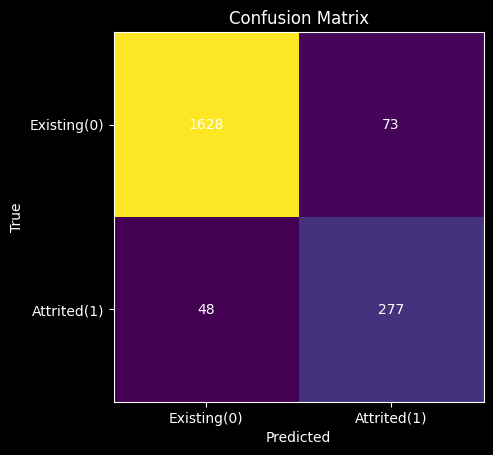

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1], ["Existing(0)", "Attrited(1)"])
plt.yticks([0,1], ["Existing(0)", "Attrited(1)"])

# Zahlen in die Matrix schreiben
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha="center", va="center")

plt.show()

## 11) (Optional) Schwellenwert statt fixem 0.5

Standard ist 0.5. In der Praxis willst du oft:
- mehr Recall (weniger Abwanderer übersehen) **oder**
- mehr Precision (weniger „unnötig anschreiben“)

Wir suchen hier den Threshold, der den **F1** auf dem Testset maximiert.

In [20]:
# Falls ein Modell predict_proba kann (LogReg / Tree / viele andere)
if not hasattr(best_model, "predict_proba"):
    print("Dieses Modell unterstützt keine Wahrscheinlichkeiten (predict_proba).")
else:
    proba = best_model.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.05, 0.95, 19)
    rows = []
    for t in thresholds:
        pred_t = (proba >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": float(precision_score(y_test, pred_t, zero_division=0)),
            "recall": float(recall_score(y_test, pred_t, zero_division=0)),
            "f1": float(f1_score(y_test, pred_t, zero_division=0)),
        })

    thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
    thr_df.head(10)

## 12) Anwenden: Vorhersage & Ranking (Top-N gefährdete Kunden)

Wir berechnen für **alle** Kunden die Abwanderungs-Wahrscheinlichkeit und erstellen ein Ranking.

Output:
- `outputs/churn_ranking_top50.csv`

In [21]:
# Ranking auf dem gesamten Datensatz (oder nur auf Bestandskunden - siehe unten)
if not hasattr(best_model, "predict_proba"):
    raise RuntimeError("Ranking braucht predict_proba. Nimm z.B. LogReg/Tree/RandomForest.")

proba_all = best_model.predict_proba(X)[:, 1]

ranking = df.copy()
ranking["churn_proba"] = proba_all

# CLIENTNUM wieder rein (falls gedroppt)
if "CLIENTNUM" in df.columns:
    ranking["CLIENTNUM"] = df["CLIENTNUM"]

# Optional: nur Bestandskunden (Existing=0) ranken
# ranking_existing = ranking[ranking[TARGET_COL] == 0].copy()
ranking_existing = ranking.copy()

cols = []
if "CLIENTNUM" in ranking_existing.columns:
    cols.append("CLIENTNUM")
cols += ["churn_proba", TARGET_COL]

top50 = (
    ranking_existing
    .sort_values("churn_proba", ascending=False)[cols]
    .head(50)
)

top50

,churn_proba,Attrition_Flag
7484,1.0,1
8167,1.0,1
9358,1.0,1
1950,1.0,1
3839,1.0,1
6598,1.0,1
9369,1.0,1
1005,1.0,1
4367,1.0,1
9382,1.0,1


In [22]:
os.makedirs("outputs", exist_ok=True)
out_path = "outputs/churn_ranking_top50.csv"
top50.to_csv(out_path, index=False)
print("Gespeichert:", out_path)

Gespeichert: outputs/churn_ranking_top50.csv


## 13) Modell speichern (für Abgabe / Demo)

Wir speichern die komplette Pipeline (inkl. Preprocessing).

In [23]:
os.makedirs("models", exist_ok=True)
model_path = "models/churn_model.joblib"
joblib.dump(best_model, model_path)
print("Gespeichert:", model_path)

Gespeichert: models/churn_model.joblib


## 14) Abgabe-Checkliste (kurz)

- [ ] Notebook läuft von oben nach unten ohne Fehler
- [ ] `data/BankChurners.csv` liegt richtig
- [ ] Ergebnisse: CV-Vergleich, Confusion Matrix, Precision/Recall/F1
- [ ] Ranking-Datei wird erzeugt (`outputs/churn_ranking_top50.csv`)
- [ ] Modell wird gespeichert (`models/churn_model.joblib`)